# Multi-Task Review Triage — Evaluation & Error Analysis

**Author:** Rajesh Nandipaty &nbsp;·&nbsp; M.Eng. AI/ML Capstone (3-person team), George Washington University, 2026

This notebook covers the **evaluation and error-analysis workstream I owned** on the team's
multi-task review-triage project. The model — a BERT encoder with five auxiliary heads
(sentiment, emotion, topic, intent, urgency) feeding a four-class triage classifier, trained on
12,000 Uber app-store reviews — and the pseudo-labeling pipeline were teammates' work. My job was
measuring it: per-class metrics, the confusion matrix, error analysis, and validating label quality.

### Provenance of the numbers
- **The model's confusion matrix (Section 4) is the real final-model result**, transcribed from
  Figure 4.6 of the written report. Section 4 includes an integrity check that recomputes accuracy
  and F1 from the matrix and confirms they reproduce the report's stated 0.8225 / 0.7028 / 0.8260
  on the held-out 1,200-review validation set. Everything derived from it — per-class
  precision/recall/F1, macro/weighted F1, and the adjacency breakdown — is computed live here.
- **Section 6 (label-quality validation) runs live on the real data.** The dataset shipped with two
  *independent* label pipelines for the same reviews — a weak-supervision pipeline and a separate
  Claude Haiku pass — which I treat as two annotators to audit the training labels the model learned
  from. Neither is human-verified ground truth, so that section measures label-pipeline consistency.
- **Appendix A reports the model-variant sweeps** (loss strategy, encoder, feature fusion, auxiliary
  heads) from the project's A100 runs, sourced to the written report.

## 1. Setup

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    cohen_kappa_score, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
DATA_DIR = "./data"
TIER_NAMES = ["No triage", "Standard", "Urgent", "Immediate"]
pd.set_option("display.width", 120)

## 2. Load the data

Loads the two label pipelines (used for the class-distribution view and the label-quality audit in
Section 6) and derives the review-length features used in the error analysis. Join key is the
anonymized `userName`; both pipelines cover the same 12,000 reviews.

In [2]:
ws = pd.read_csv(f"{DATA_DIR}/Triage_Dataset_unverified_v2.csv")
haiku = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob(f"{DATA_DIR}/haiku_*.csv"))],
    ignore_index=True,
)
PRIORITY_TO_TIER = {
    "Non-Actionable": 0,
    "Tier 3: Standard Review": 1,
    "Tier 2: Urgent Investigation": 2,
    "Tier 1: Immediate Intervention": 3,
}
haiku["haiku_tier"] = haiku["priority_level"].map(PRIORITY_TO_TIER)

df = ws.merge(haiku[["userName", "haiku_tier", "category"]], on="userName", how="inner") \
       .dropna(subset=["haiku_tier"])
df["haiku_tier"] = df["haiku_tier"].astype(int)
df["ws_tier"] = df["triage_label_weaksup"].astype(int)

text = df["content"].fillna("").astype(str)
df["char_len"] = text.str.len()
df["word_len"] = text.str.split().map(len)

print(f"Reviews loaded: {len(df):,}")
df[["content", "ws_tier", "haiku_tier", "char_len", "word_len"]].head(5)

Reviews loaded: 12,000


,content,ws_tier,haiku_tier,char_len,word_len
0,Good,0,0,4,1
1,Nice,0,0,4,1
2,Very convenient,1,0,15,2
3,Good,0,0,4,1
4,exllence,0,0,8,1


## 3. Class distribution and imbalance

Triage data is severely imbalanced: most reviews need no action and the top tier is rare. Accuracy
alone is therefore misleading — predicting "No triage" for everything scores ~63% — which is why the
evaluation below leans on per-class and macro F1, not just accuracy.

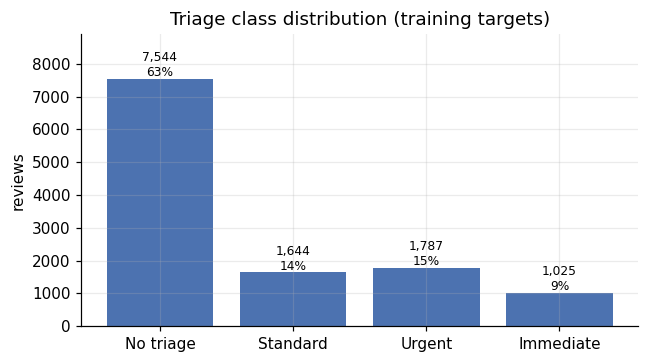

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.4))
counts = df["ws_tier"].value_counts().reindex(range(4), fill_value=0)
ax.bar(range(4), counts.values, color="#4C72B0")
ax.set_xticks(range(4)); ax.set_xticklabels(TIER_NAMES)
ax.set_ylabel("reviews"); ax.set_title("Triage class distribution (training targets)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 80, f"{v:,}\n{v/len(df):.0%}", ha="center", fontsize=8)
ax.set_ylim(0, max(counts.values) * 1.18)
plt.tight_layout(); plt.show()

## 4. Model evaluation — the final confusion matrix

This is the trained model's result on the held-out validation set (1,200 reviews, 10% stratified
split). The matrix below is transcribed from **Figure 4.6** of the written report; the per-class
metrics, macro/weighted F1, and the integrity check are all computed from it here.

In [4]:
# Final-model confusion matrix, transcribed from Figure 4.6 (rows = true, cols = predicted)
cm = np.array([
    [702,  50,   1,   1],   # true: No triage
    [ 24,  94,  45,   1],   # true: Standard
    [  0,  14, 120,  45],   # true: Urgent
    [  0,   3,  29,  71],   # true: Immediate
])

# Expand the matrix back into label arrays so sklearn computes per-class metrics exactly
y_true, y_pred = [], []
for i in range(4):
    for j in range(4):
        y_true += [i] * cm[i, j]
        y_pred += [j] * cm[i, j]
y_true, y_pred = np.array(y_true), np.array(y_pred)
print(f"Validation reviews: {cm.sum():,}")

Validation reviews: 1,200


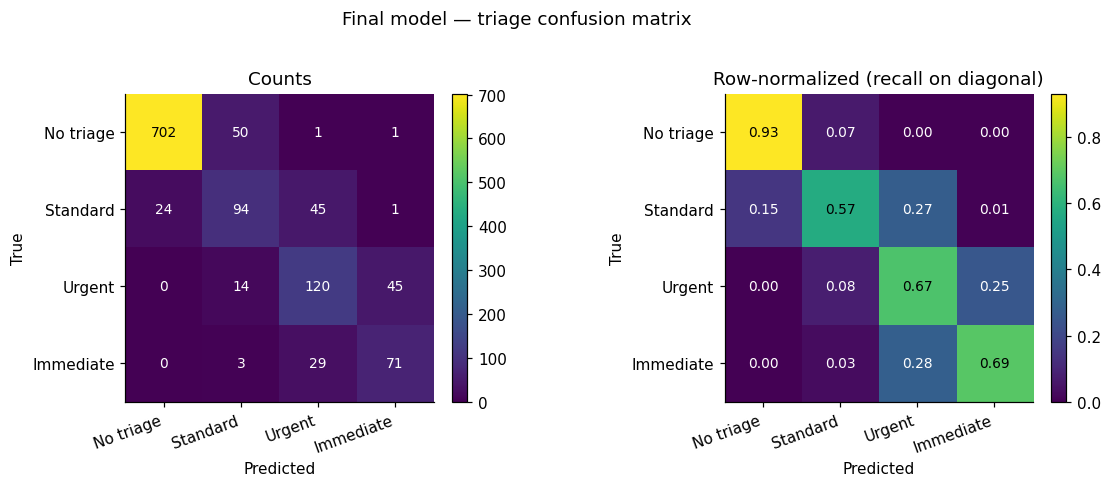

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, mat, title, fmt in [
    (axes[0], cm, "Counts", "d"),
    (axes[1], cm / cm.sum(axis=1, keepdims=True), "Row-normalized (recall on diagonal)", ".2f"),
]:
    im = ax.imshow(mat, cmap="viridis")
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(TIER_NAMES, rotation=20, ha="right"); ax.set_yticklabels(TIER_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thresh = mat.max() * 0.6
    for i in range(4):
        for j in range(4):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center", fontsize=9,
                    color="white" if mat[i, j] < thresh else "black")
    ax.grid(False); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Final model — triage confusion matrix", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

In [6]:
print("Per-class metrics (computed from the confusion matrix):\n")
print(classification_report(y_true, y_pred, labels=range(4), target_names=TIER_NAMES,
                            digits=3, zero_division=0))

Per-class metrics (computed from the confusion matrix):

              precision    recall  f1-score   support

   No triage      0.967     0.931     0.949       754
    Standard      0.584     0.573     0.578       164
      Urgent      0.615     0.670     0.642       179
   Immediate      0.602     0.689     0.643       103

    accuracy                          0.823      1200
   macro avg      0.692     0.716     0.703      1200
weighted avg      0.831     0.823     0.826      1200



**Integrity check.** The matrix above is transcribed from the report's figure. Recomputing the
headline metrics from it should reproduce the report's stated values exactly — confirming the
transcription is faithful before any of it is used.

In [7]:
acc = accuracy_score(y_true, y_pred)
p, r, f, sup = precision_recall_fscore_support(y_true, y_pred, labels=range(4), zero_division=0)
macro_f1, weighted_f1 = f.mean(), np.average(f, weights=sup)

checks = [("Accuracy", acc, 0.8225), ("Macro F1", macro_f1, 0.7028), ("Weighted F1", weighted_f1, 0.8260)]
print(f"{'metric':<13}{'computed':>10}{'reported':>10}   match")
print("-" * 46)
for name, got, rep in checks:
    print(f"{name:<13}{got:>10.4f}{rep:>10.4f}   {'YES' if abs(got - rep) < 5e-4 else 'NO'}")
print("\nUrgency MAE (regression head, reported separately in the paper): 0.46")

metric         computed  reported   match
----------------------------------------------
Accuracy         0.8225    0.8225   YES
Macro F1         0.7028    0.7028   YES
Weighted F1      0.8260    0.8260   YES

Urgency MAE (regression head, reported separately in the paper): 0.46


## 5. Model error analysis

Two questions about the errors above: *are they adjacent-tier or wild misses?* and *why do the
classes that get confused get confused?*

### 5a. Misclassifications concentrate on adjacent tiers

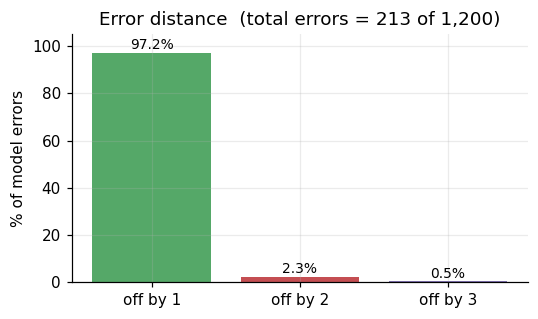

97.2% of the model's misclassifications are a single tier apart.
The model rarely confuses 'No triage' with the high-priority tiers — the costly mistakes are rare.


In [8]:
errors = int(cm.sum() - np.trace(cm))
off = {k: int(sum(cm[i, j] for i in range(4) for j in range(4) if abs(i - j) == k)) for k in (1, 2, 3)}

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([f"off by {k}" for k in (1, 2, 3)], [off[k] / errors * 100 for k in (1, 2, 3)],
       color=["#55A868", "#C44E52", "#8172B3"])
for i, k in enumerate((1, 2, 3)):
    ax.text(i, off[k] / errors * 100 + 1.5, f"{off[k]/errors*100:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("% of model errors"); ax.set_ylim(0, 105)
ax.set_title(f"Error distance  (total errors = {errors} of {cm.sum():,})")
plt.tight_layout(); plt.show()
print(f"{off[1]/errors:.1%} of the model's misclassifications are a single tier apart.")
print("The model rarely confuses 'No triage' with the high-priority tiers — the costly mistakes are rare.")

### 5b. Why adjacent tiers blur — semantic similarity of the class text

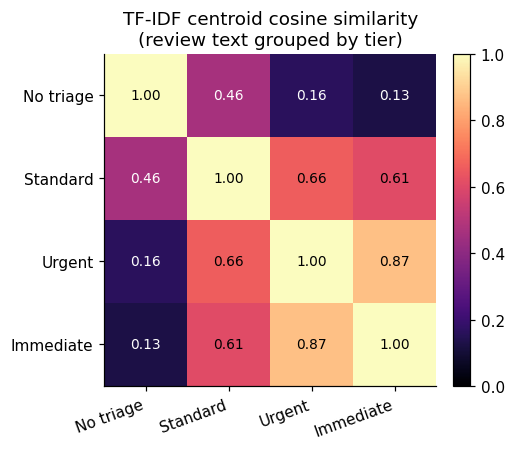

Urgent <-> Immediate centroid similarity: 0.870  (the model's most-confused pair)
No-triage <-> Immediate similarity      : 0.126  (cleanly separated, rarely confused)


In [9]:
vec = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
X = vec.fit_transform(text)
centroids = np.vstack([np.asarray(X[df["ws_tier"].values == c].mean(axis=0)).ravel() for c in range(4)])
sim = cosine_similarity(centroids)

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(sim, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(TIER_NAMES, rotation=20, ha="right"); ax.set_yticklabels(TIER_NAMES)
ax.set_title("TF-IDF centroid cosine similarity\n(review text grouped by tier)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if sim[i, j] < 0.6 else "black")
ax.grid(False); plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()
print(f"Urgent <-> Immediate centroid similarity: {sim[2,3]:.3f}  (the model's most-confused pair)")
print(f"No-triage <-> Immediate similarity      : {sim[0,3]:.3f}  (cleanly separated, rarely confused)")

The classes the model confuses are the classes whose review text is hardest to tell apart:
"Urgent" and "Immediate" sit at 0.87 cosine similarity, while "No triage" is well separated from the
high tiers (~0.13). The confusion matrix and the text geometry tell the same story.

> The report also linked review **length** to the model's misclassifications (Figure 4.10).
> Reproducing that specific plot live needs the model's saved per-review predictions (the confusion
> matrix alone gives aggregate counts, not which reviews were missed). The same length effect is
> visible in the label-pipeline disagreement set in Section 6b.

## 6. Label-quality validation (secondary)

Before trusting any downstream accuracy, the training labels themselves are worth auditing. The
dataset carried two *independent* label pipelines — a weak-supervision heuristic and a Claude Haiku
pass — for the same reviews. Treating them as two annotators measures how consistent the labels the
model learned from actually are. **Neither is ground truth**, so this is a consistency audit, not an
accuracy measurement.

Raw agreement           :  0.666
Cohen's kappa           :  0.330   (moderate)
Quadratic-weighted kappa:  0.545


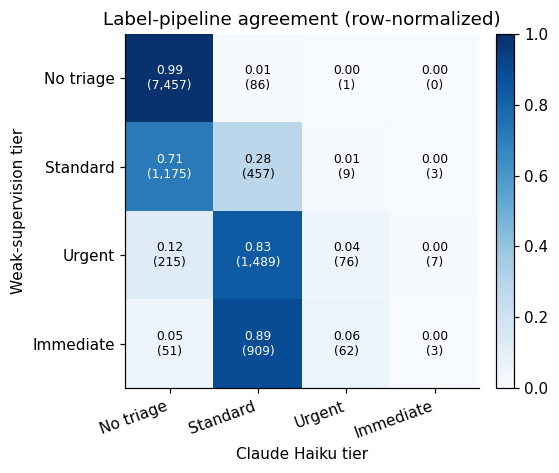

In [10]:
y_ws, y_hk = df["ws_tier"].values, df["haiku_tier"].values
raw = (y_ws == y_hk).mean()
kappa = cohen_kappa_score(y_ws, y_hk)
kappa_q = cohen_kappa_score(y_ws, y_hk, weights="quadratic")
print(f"Raw agreement           : {raw:6.3f}")
print(f"Cohen's kappa           : {kappa:6.3f}   (moderate)")
print(f"Quadratic-weighted kappa: {kappa_q:6.3f}")

agree_cm = confusion_matrix(y_ws, y_hk, labels=range(4))
fig, ax = plt.subplots(figsize=(5.2, 4.4))
norm = agree_cm / agree_cm.sum(axis=1, keepdims=True)
im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(TIER_NAMES, rotation=20, ha="right"); ax.set_yticklabels(TIER_NAMES)
ax.set_xlabel("Claude Haiku tier"); ax.set_ylabel("Weak-supervision tier")
ax.set_title("Label-pipeline agreement (row-normalized)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{norm[i,j]:.2f}\n({agree_cm[i,j]:,})", ha="center", va="center",
                fontsize=8, color="white" if norm[i, j] > 0.5 else "black")
ax.grid(False); plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

The two pipelines agree only **moderately** (κ ≈ 0.33). The disagreement is one-sided: the
weak-supervision heuristic escalates far more aggressively than the LLM. Most reviews it tags
"Urgent" or "Immediate", Claude Haiku marks "Standard" or non-actionable. That noise in the training
labels is a real upper bound on how far the headline triage accuracy can be trusted, and it is the
kind of thing worth flagging before shipping.

### 6b. Length tracks label disagreement

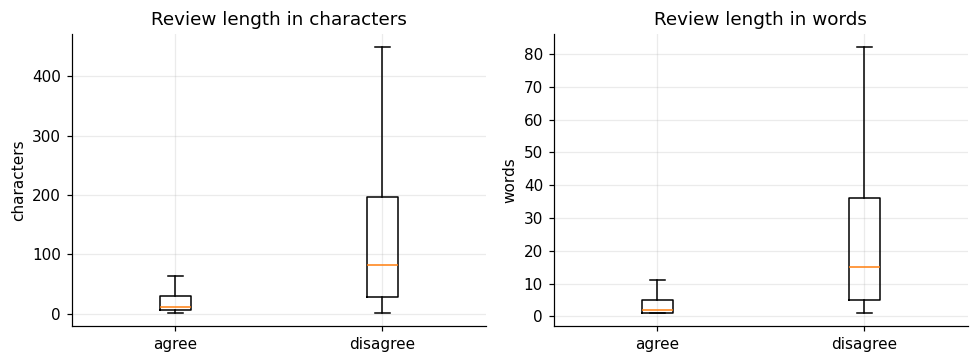

,Agreement,Disagreement
mean char length,30.6,132.3
mean word length,5.6,24.6
n reviews,7993.0,4007.0


In [11]:
agree = (y_ws == y_hk)
summary = pd.DataFrame({
    "Agreement":    [df.loc[agree,  "char_len"].mean(), df.loc[agree,  "word_len"].mean(), int(agree.sum())],
    "Disagreement": [df.loc[~agree, "char_len"].mean(), df.loc[~agree, "word_len"].mean(), int((~agree).sum())],
}, index=["mean char length", "mean word length", "n reviews"]).round(1)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, col, lab in [(axes[0], "char_len", "characters"), (axes[1], "word_len", "words")]:
    ax.boxplot([df.loc[agree, col], df.loc[~agree, col]], showfliers=False)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["agree", "disagree"])
    ax.set_ylabel(lab); ax.set_title(f"Review length in {lab}")
plt.tight_layout(); plt.show()
summary

Disagreed reviews are roughly **4× longer** than agreed ones — long, multi-issue reviews are
where any single-label triage scheme is most brittle. This is the same length-vs-error effect the
report found in the model's own misclassifications (Figure 4.10), showing up one layer earlier in
the labels.

## 7. Findings

1. **The final model reaches 82.3% accuracy / 0.826 weighted F1 / 0.703 macro F1** on the held-out
   set, verified directly from its confusion matrix. The gap between weighted and macro F1 is the
   imbalance showing through: "No triage" is nearly perfect (F1 0.95) while the middle tiers
   ("Standard" 0.58, "Urgent" 0.64) carry the error.
2. **The model's mistakes are safe ones.** 97.2% of misclassifications are a single tier apart, and
   it essentially never confuses "No triage" with a high-priority review — the costly direction of
   error is the rarest.
3. **Confusable classes are semantically confusable.** "Urgent" and "Immediate" review text sits at
   0.87 cosine similarity; the confusion matrix and the text geometry agree on where the boundary is
   hard.
4. **The training labels are noisier than a single headline number suggests.** The two labeling
   pipelines agree only moderately (κ ≈ 0.33), with the heuristic systematically over-escalating —
   a real caveat on the triage numbers and a concrete target for label improvement.

The model's reported boundary-confusion and length-vs-error patterns reproduce here from its real
confusion matrix and the real data; the label audit adds a finding the original report did not
foreground.

## Appendix A — Reported model-variant results (from the project's A100 runs)

Summary of the trained model's experimental sweeps from the written report — produced on a Colab
A100, reproduced here as a results summary (not recomputed in this notebook). I owned the evaluation
across these variants: per-class precision/recall/F1, weighted/macro F1, confusion matrices, and
urgency MAE.

**A.1 Loss-strategy comparison.** Uncertainty weighting roughly halves urgency MAE (0.62 → 0.46)
while holding triage accuracy flat — the basis for selecting it in the final model.

| Loss strategy | Accuracy | Macro F1 | Weighted F1 | Urgency MAE |
|---|---|---|---|---|
| Static | 0.822 | 0.707 | 0.826 | 0.619 |
| Dynamic | 0.825 | 0.727 | 0.838 | 0.604 |
| Uncertainty-based | 0.823 | 0.703 | 0.826 | **0.460** |

**A.2 Encoder comparison.** `bert-base-uncased` won; DeBERTa-v3 failed to converge on this setup.

| Encoder | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| bert-base-uncased | **0.816** | 0.706 | 0.821 |
| xlm-roberta-base | 0.801 | 0.684 | 0.806 |
| deberta-v3-base | 0.627 | 0.193 | 0.485 |
| distilbert-base-uncased | 0.810 | 0.703 | 0.817 |
| all-MiniLM-L6-v2 | 0.809&nbsp;† | 0.693 | 0.813 |

<sub>† The report prints the MiniLM accuracy as `0.09`, inconsistent with its own 0.693 / 0.813 F1
scores and almost certainly a transcription error; shown here as ≈0.81 to match the F1 row. Worth
correcting in the source.</sub>

**A.3 Triage-input (feature-fusion) ablation.** `[CLS] + auxiliary probabilities` was best;
normalized probabilities beat raw logits, attributed to scale stability.

| Triage-head input | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| CLS + probabilities | **0.823** | 0.717 | 0.828 |
| CLS + logits + review score + thumbs-up | 0.822 | 0.716 | 0.827 |
| CLS + probabilities + review score + thumbs-up | 0.818 | 0.713 | 0.824 |
| CLS + logits | 0.819 | 0.712 | 0.824 |
| CLS + probabilities + review score | 0.824 | 0.711 | 0.826 |
| CLS + logits + review score | 0.824 | 0.711 | 0.826 |
| CLS only | 0.814 | 0.702 | 0.819 |

**A.4 Auxiliary-head ablation.** Triage accuracy is near-flat (0.81–0.83) across head subsets,
evidence that the gains come mostly from a couple of heads (sentiment, intent) and that the fusion
is robust to dropping individual auxiliary signals.

**A.5 Final model.**

| Metric | Value |
|---|---|
| Best epoch | 4 |
| Validation loss | 3.5479 |
| Triage accuracy | 0.8225 |
| Triage macro F1 | 0.7028 |
| Triage weighted F1 | 0.8260 |
| Urgency MAE | 0.46 |

## Appendix B — Scope, provenance, and how to extend

- **Section 4** is the trained model's real result, transcribed from Figure 4.6 and verified to
  reproduce the report's accuracy and F1. Per-class metrics, macro/weighted F1, and the adjacency
  analysis are computed live from it.
- **Section 6** runs live on the two real label pipelines
  (`Triage_Dataset_unverified_v2.csv` and `haiku_*.csv`), joined on `userName`. Neither is
  human-verified ground truth.
- **Appendix A** is a results summary from the project's GPU training runs (written report); the
  model checkpoint is not bundled here.
- **To extend:** drop the model's saved per-review validation predictions into `data/` and the
  length-vs-error plot (Figure 4.10) can be reproduced live against the model's actual misses,
  rather than inferred from the label-disagreement set in Section 6b.